<a href="https://colab.research.google.com/github/Dre448/CP2-SERS/blob/main/Aula_APIs_Energia_Renovavel_ML_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [36]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [37]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [38]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [39]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [40]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [41]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [42]:
#Preparar ambiente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score , confusion_matrix

In [43]:
#1.
dados = pd.read_csv('/content/aneel_classificacao_orange.csv')
dados.head()
print("Valores ausentes na tabela:",dados.isnull().sum())
print("Quantidade de linhas e colunas",dados.shape)
dados.info()
print("As classes são: ",dados['fonte'].unique())

Valores ausentes na tabela: potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64
Quantidade de linhas e colunas (3876, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB
As classes são:  ['Solar' 'Eólica' 'Hidráulica']


**X (entradas):** `potencia_kw`, `latitude` e `longitude`.

**y (alvo):** `fonte` (Solar, Eólica ou Hidráulica).

A potência tem valores muito diferentes entre si (de poucos kW a milhares de kW). Por isso foi usado o `log(1 + potência)`. Depois, as três entradas foram padronizadas usando a média e o desvio padrão **somente do treino**.

In [52]:
#3.
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("Treino:", X_treino.shape)
print("Teste:", X_teste.shape)

Treino: (3100, 3)
Teste: (776, 3)


**Os três classificadores escolhidos:**

1. **Regressão Logística:** modelo simples que separa as classes com fronteiras retas.
2. **KNN (k = 5):** olha os 5 empreendimentos mais parecidos do treino e escolhe a classe mais comum entre eles.
3. **Centroide mais próximo:** calcula o ponto médio de cada classe e escolhe a classe cujo ponto médio está mais perto.

Os três usam a mesma divisão de treino e teste.

In [53]:
#4.
def knn_classificar(X_treino, y_treino, X_novo, k=5):
    previsoes = []
    for linha in X_novo:
        distancias = np.sqrt(((X_treino - linha) ** 2).sum(axis=1))
        posicoes = np.argsort(distancias)[:k]
        vizinhos = y_treino[posicoes]
        nomes, contagens = np.unique(vizinhos, return_counts=True)
        previsoes.append(nomes[np.argmax(contagens)])
    return np.array(previsoes)

def centroide_classificar(X_treino, y_treino, X_novo):
    centros = []
    for classe in classes:
        centros.append(X_treino[y_treino == classe].mean(axis=0))
    centros = np.array(centros)
    previsoes = []
    for linha in X_novo:
        distancias = np.sqrt(((centros - linha) ** 2).sum(axis=1))
        previsoes.append(classes[np.argmin(distancias)])
    return np.array(previsoes)

modelo_log = LogisticRegression(max_iter=1000, random_state=42)
modelo_log.fit(X_treino, y_treino)

previsoes = {}
previsoes["Regressão Logística"] = modelo_log.predict(X_teste)
previsoes["KNN (k=5)"] = knn_classificar(X_treino, y_treino, X_teste, k=5)
previsoes["Centroide mais próximo"] = centroide_classificar(X_treino, y_treino, X_teste)
print("Modelos treinados")

Modelos treinados


Média usada nas métricas por classe: macro
                        Accuracy  Precision (macro)  Recall (macro)  \
Modelo                                                                
Regressão Logística       0.8338             0.8502          0.8295   
KNN (k=5)                 0.9652             0.9656          0.9636   
Centroide mais próximo    0.8338             0.8485          0.8306   

                        F1 (macro)  
Modelo                              
Regressão Logística         0.8286  
KNN (k=5)                   0.9644  
Centroide mais próximo      0.8290  


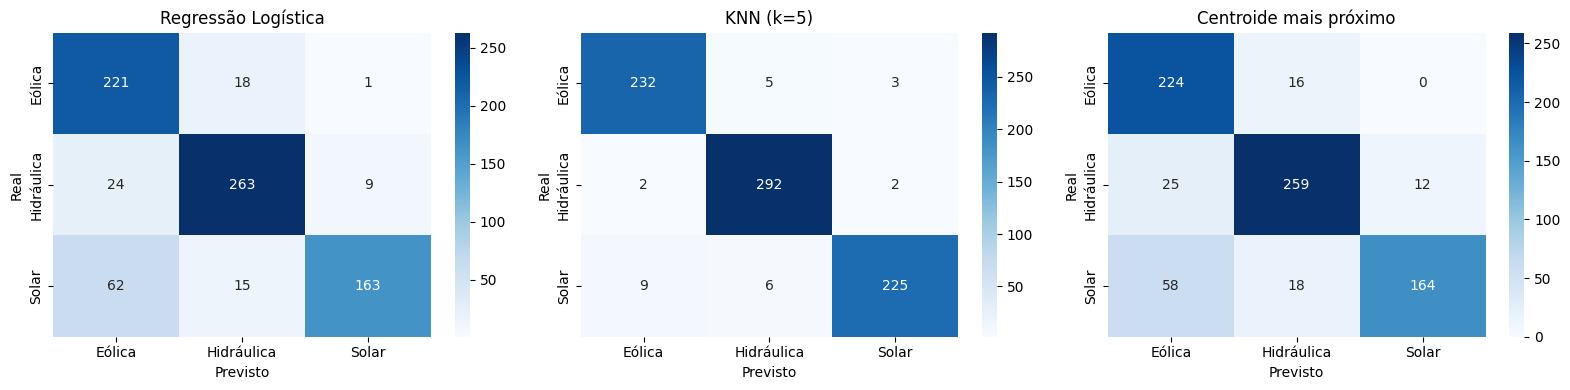

Modelo escolhido (maior F1 macro): KNN (k=5)
Mais confundido: 9 casos da classe Solar previstos como Eólica


In [55]:
#4.
linhas = []
for nome in previsoes:
    pred = previsoes[nome]
    cm = confusion_matrix(y_teste, pred, labels=classes)
    precisoes = precision_score(y_teste, pred, labels=classes, average=None, zero_division=0)
    recalls = []
    f1s = []
    for i in range(len(classes)):
        recall = cm[i, i] / cm[i, :].sum()
        recalls.append(recall)
        if precisoes[i] + recall == 0:
            f1s.append(0)
        else:
            f1s.append(2 * precisoes[i] * recall / (precisoes[i] + recall))
    linhas.append([nome, accuracy_score(y_teste, pred), np.mean(precisoes), np.mean(recalls), np.mean(f1s)])

tabela_clf = pd.DataFrame(linhas, columns=["Modelo","Accuracy","Precision (macro)","Recall (macro)","F1 (macro)"])
tabela_clf = tabela_clf.set_index("Modelo").round(4)
print("Média usada nas métricas por classe: macro")
print(tabela_clf)

fig, eixos = plt.subplots(1, 3, figsize=(16,4))
for i, nome in enumerate(previsoes):
    cm = confusion_matrix(y_teste, previsoes[nome], labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=eixos[i])
    eixos[i].set_title(nome)
    eixos[i].set_xlabel("Previsto")
    eixos[i].set_ylabel("Real")
plt.tight_layout()
plt.show()

melhor = tabela_clf['F1 (macro)'].idxmax()
print("Modelo escolhido (maior F1 macro):", melhor)

cm = confusion_matrix(y_teste, previsoes[melhor], labels=classes)
maior_erro = 0
for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j and cm[i, j] > maior_erro:
            maior_erro = cm[i, j]
            real = classes[i]
            previsto = classes[j]
print("Mais confundido:", maior_erro, "casos da classe", real, "previstos como", previsto)

**Interpretação — classificação**

- O modelo escolhido é o que aparece na célula anterior (maior F1 macro). O F1 é uma boa escolha porque mistura precision e recall e trata todas as classes com o mesmo peso, mesmo quando uma classe tem menos exemplos.
- A célula anterior mostra também qual par de classes o modelo mais confunde.
- Potência e localização não bastam para uma aplicação real: usinas de fontes diferentes podem ter potências parecidas e ficar na mesma região. Também faltam informações importantes, como o tipo de tecnologia, a data, o relevo, a existência de rio e o vento e o sol do local.
- A potência é a potência outorgada (autorizada), e não a energia realmente gerada.
- As quantidades da consulta têm limite por tipo, então não representam a participação real de cada fonte no Brasil.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [45]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [46]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [47]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [48]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [56]:
#1
dados_meteo = pd.read_csv('/content/meteo_regressao_orange.csv')
dados_meteo = dados_meteo.sort_values('data_hora').reset_index(drop=True)
dados_meteo.head()
print("Valores ausentes na tabela:",dados_meteo.isnull().sum())
print("Quantidade de linhas e colunas",dados_meteo.shape)
dados_meteo.info()
print(dados_meteo.describe())

Valores ausentes na tabela: data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64
Quantidade de linhas e colunas (1001, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB
       temperatura_c  umidade_pct   nuvens_pct    vento_kmh         hora  \
count    1001.000000  1001.000000  1001.000000  1001.000000  1001.000000   
mean       28.885914    50.544456    55.108891    15.465435    12.00

In [60]:
#2.
colunas_x = ['temperatura_c','umidade_pct','nuvens_pct','vento_kmh','hora']
X = dados_meteo[colunas_x]
y = dados_meteo['radiacao_w_m2'].values

corte = int(len(dados_meteo) * 0.8)
X_treino = X.iloc[:corte]
X_teste = X.iloc[corte:]
y_treino = y[:corte]
y_teste = y[corte:]

media = X_treino.mean()
desvio = X_treino.std()
X_treino = ((X_treino - media) / desvio).values
X_teste = ((X_teste - media) / desvio).values

print("Treino:", X_treino.shape, "de", dados_meteo['data_hora'].iloc[0], "até", dados_meteo['data_hora'].iloc[corte-1])
print("Teste:", X_teste.shape, "de", dados_meteo['data_hora'].iloc[corte], "até", dados_meteo['data_hora'].iloc[-1])

Treino: (800, 5) de 2025-04-01T07:00 até 2025-06-12T14:00
Teste: (201, 5) de 2025-06-12T15:00 até 2025-06-30T17:00


**Colunas:** `data_hora` (data e hora local), `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora` (7 a 17) e `radiacao_w_m2` (radiação solar em W/m²).

**X (cinco entradas):** `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh` e `hora`.

**y (alvo):** `radiacao_w_m2`.

`data_hora` só serve para ordenar e separar treino e teste. As primeiras 80% das horas foram usadas para treino e as últimas 20% para teste, sem embaralhar.

In [59]:
#3.
colunas_x = ['temperatura_c','umidade_pct','nuvens_pct','vento_kmh','hora']
X = dados_meteo[colunas_x]
y = dados_meteo['radiacao_w_m2'].values

corte = int(len(dados_meteo) * 0.8)
X_treino = X.iloc[:corte]
X_teste = X.iloc[corte:]
y_treino = y[:corte]
y_teste = y[corte:]

media = X_treino.mean()
desvio = X_treino.std()
X_treino = ((X_treino - media) / desvio).values
X_teste = ((X_teste - media) / desvio).values

print("Treino:", X_treino.shape, "de", dados_meteo['data_hora'].iloc[0], "até", dados_meteo['data_hora'].iloc[corte-1])
print("Teste:", X_teste.shape, "de", dados_meteo['data_hora'].iloc[corte], "até", dados_meteo['data_hora'].iloc[-1])

Treino: (800, 5) de 2025-04-01T07:00 até 2025-06-12T14:00
Teste: (201, 5) de 2025-06-12T15:00 até 2025-06-30T17:00


**Os três algoritmos de regressão escolhidos:**

1. **Regressão Linear:** ajusta uma reta (um plano) entre as entradas e a radiação.
2. **Regressão Polinomial (grau 2):** igual à linear, mas também usa as entradas ao quadrado. Isso permite formar curvas, como o "morrinho" da radiação ao longo do dia.
3. **KNN Regressor (k = 5):** prevê a média da radiação das 5 horas mais parecidas do treino.

In [61]:
#3.
def treinar_linear(X_treino, y_treino):
    A = np.column_stack([np.ones(len(X_treino)), X_treino])
    coeficientes = np.linalg.lstsq(A, y_treino, rcond=None)[0]
    return coeficientes

def prever_linear(coeficientes, X_novo):
    A = np.column_stack([np.ones(len(X_novo)), X_novo])
    return A @ coeficientes

def knn_regredir(X_treino, y_treino, X_novo, k=5):
    previsoes = []
    for linha in X_novo:
        distancias = np.sqrt(((X_treino - linha) ** 2).sum(axis=1))
        posicoes = np.argsort(distancias)[:k]
        previsoes.append(y_treino[posicoes].mean())
    return np.array(previsoes)

coef_linear = treinar_linear(X_treino, y_treino)

X_treino_poly = np.column_stack([X_treino, X_treino ** 2])
X_teste_poly = np.column_stack([X_teste, X_teste ** 2])
coef_poly = treinar_linear(X_treino_poly, y_treino)

previsoes = {}
previsoes["Regressão Linear"] = prever_linear(coef_linear, X_teste)
previsoes["Regressão Polinomial (grau 2)"] = prever_linear(coef_poly, X_teste_poly)
previsoes["KNN Regressor (k=5)"] = knn_regredir(X_treino, y_treino, X_teste, k=5)
print("Modelos treinados")

Modelos treinados


                               MAE (W/m²)  MSE ((W/m²)²)      R²
Modelo                                                          
Regressão Linear                 145.2049     30034.2011  0.3598
Regressão Polinomial (grau 2)     84.4355     10213.7385  0.7823
KNN Regressor (k=5)               68.2706      7607.9614  0.8378


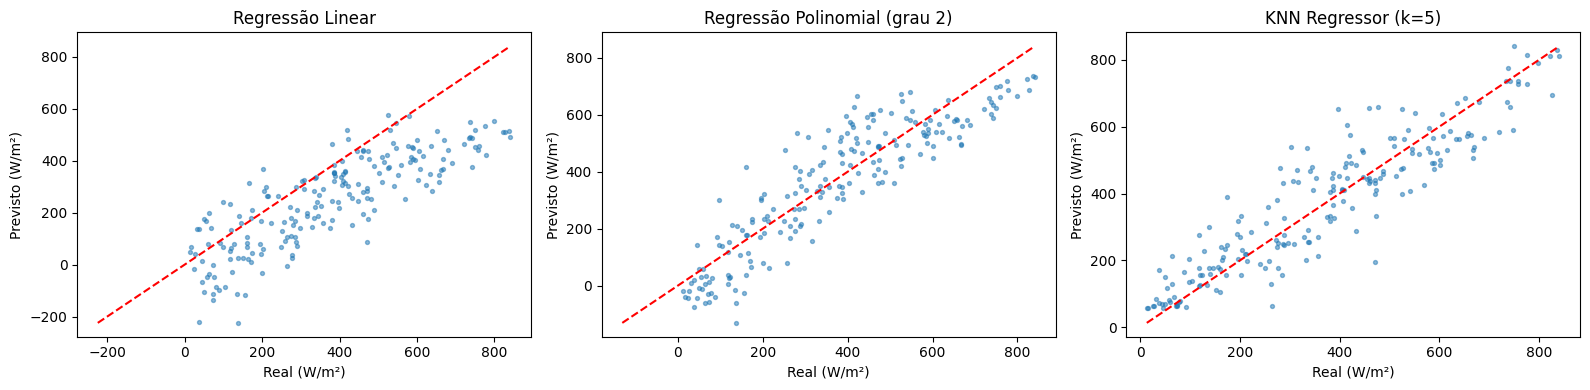

Melhor modelo (maior R²): KNN Regressor (k=5)
Coeficientes da Regressão Linear (entradas padronizadas):
temperatura_c 348.77
umidade_pct 21.95
nuvens_pct -9.72
vento_kmh 46.79
hora -201.57
Erro médio (MAE) por hora no teste, modelo KNN Regressor (k=5)
hora
7     33.5
8     46.1
9     67.5
10    75.1
11    69.8
12    90.4
13    74.6
14    76.2
15    71.9
16    86.5
17    58.7
Name: erro_abs, dtype: float64


In [64]:
#4.
linhas = []
for nome in previsoes:
    erro = y_teste - previsoes[nome]
    mae = np.mean(np.abs(erro))
    mse = np.mean(erro ** 2)
    r2 = 1 - np.sum(erro ** 2) / np.sum((y_teste - y_teste.mean()) ** 2)
    linhas.append([nome, mae, mse, r2])

tabela_reg = pd.DataFrame(linhas, columns=["Modelo","MAE (W/m²)","MSE ((W/m²)²)","R²"])
tabela_reg = tabela_reg.set_index("Modelo").round(4)
print(tabela_reg)

fig, eixos = plt.subplots(1, 3, figsize=(16,4))
for i, nome in enumerate(previsoes):
    eixos[i].scatter(y_teste, previsoes[nome], s=8, alpha=0.5)
    minimo = min(y_teste.min(), previsoes[nome].min())
    maximo = max(y_teste.max(), previsoes[nome].max())
    eixos[i].plot([minimo, maximo], [minimo, maximo], color='red', linestyle='--')
    eixos[i].set_title(nome)
    eixos[i].set_xlabel("Real (W/m²)")
    eixos[i].set_ylabel("Previsto (W/m²)")
plt.tight_layout()
plt.show()

melhor = tabela_reg['R²'].idxmax()
print("Melhor modelo (maior R²):", melhor)

print("Coeficientes da Regressão Linear (entradas padronizadas):")
for nome, valor in zip(colunas_x, coef_linear[1:]):
    print(nome, round(valor, 2))

teste_meteo = dados_meteo.iloc[corte:].copy()
teste_meteo['erro_abs'] = np.abs(y_teste - previsoes[melhor])
print("Erro médio (MAE) por hora no teste, modelo", melhor)
print(teste_meteo.groupby('hora')['erro_abs'].mean().round(1))

**Interpretação — regressão**

- Os erros do melhor modelo (MAE em W/m²) devem ser comparados com a radiação média da amostra, mostrada em `describe()`. O R² diz quanto da variação da radiação o modelo consegue explicar.
- A tabela de erro por hora mostra em quais horas o modelo erra mais. A radiação muda muito ao longo do dia (é baixa de manhã cedo, alta perto do meio-dia e cai no fim da tarde), então a `hora` tem um peso grande. O modelo linear não consegue desenhar esse formato de curva sozinho, e por isso a regressão polinomial e o KNN tendem a se sair melhor.
- As nuvens diminuem a radiação: quanto mais nuvens, menor a radiação.
- Estimar a radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico. A radiação é medida em W/m² (potência por área), e a energia é medida em kWh (potência ao longo do tempo). A geração real também depende do tamanho e da eficiência dos painéis, da inclinação, da sujeira, da temperatura do painel, das perdas do inversor e da rede elétrica.
- Os dados são estimados por modelos (reanálise), e não medidos por um sensor do local.

### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)